In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt,HyperAuto
from mllib import Utilities,MLUtilities

from time import time
import copy

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

ut = Utilities()
ml = MLUtilities()

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 14
FSS = 12
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of `AutoEncoder`  
### using `Sequential` with `HyperAuto`/`HyperOpt` for optimization

## Examples: MNIST, SVD

In [3]:
Example = 'mnist' # 'mnist','svd'
Ensemble = True   # whether or not to use ensemble

if Example == 'mnist':
    Downsample = 0.5  # 1.0 is doable on desktop: reaches ~59.6GB RAM using N = 3 x 48 jobs, scales ~ 1/N
    Select_k = np.arange(10) #[0,1]  # list of digits to include in data
    K = len(Select_k) # number of digits included  
if Example == 'svd':
    NonLinear = True  # whether or not to implement nonlinearity.
    D = 5             # dimensionality. Set >= 2 for interesting problems
    n_rot = 0         # number of rotations to apply [<= (D choose 3)]
    n_NL = 10         # number of pairs of dimensions to combine nonlinearly [<= (D choose 2)]

In [4]:
Out_Stem = 'autoencoder/'
Plot_Stem = Out_Stem + 'plots'
ExDict = {'mnist':{'text':'MNIST', # text will be updated below
                   'nproc':1},     # large mem reqs for MNIST mean 1 is best
          'svd':{'text':'SVD','nproc':16}
         }

if Example not in ExDict.keys():
    raise Exception("Unrecognised example '"+Example+"'")

Out_Stem += Example + '/'
Plot_Root = Example + '_'
if Example == 'mnist':
    if K < 10:
        k_dir = 'k' + ''.join([str(k) for k in Select_k])
        k_text = 'k=[' + ','.join([str(k) for k in Select_k]) + ']'
    else:
        k_dir = 'all'
        k_text = 'all digits'
    Out_Stem += k_dir + '/'
    Plot_Root += k_dir + '_'
    ExDict['mnist']['text'] += " ({0:.0f}%;".format(100*Downsample) + k_text + ')'
if Example == 'svd':
    nl_dir = 'non' if NonLinear else ''
    nl_dir += 'linear'
    nl_text = '' + nl_dir
    Out_Stem += nl_dir + '/'
    Plot_Root += nl_dir + '_'
    ExDict['svd']['text'] += ' (' + nl_text + ')'

Plot_Root = Plot_Stem + '/' + Plot_Root
if Ensemble:
    Plot_Root += 'ens_'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)
print(Out_Stem,ExDict[Example]['text'],Plot_Root)

Nproc = ExDict[Example]['nproc']

Save_Fig = True

autoencoder/mnist/all/ MNIST (50%;all digits) autoencoder/plots/mnist_all_ens_


### Data setup

In [5]:
if Example == 'svd':
    from scipy.spatial.transform import Rotation
    import itertools
    
    n_train = 5000
    n_test = 2000
    Show_Dist = False
    
    Seed = 42    
    rng = np.random.RandomState(Seed)

    if NonLinear & (D < 2):
        raise Exception("Nonlinearity can't be implemented in less than 2 dimensions!")
    NL_Pairs = []
    for comb in itertools.combinations(np.arange(D), 2):
        NL_Pairs.append(list(comb))    
    rng.shuffle(NL_Pairs)
    NL_Expos = np.linspace(0.5,2.5,len(NL_Pairs)) # mild to strong nonlinearity
    NL_Amps  = np.logspace(-1.5,-0.5,len(NL_Pairs))[::-1]
    
    # setup covariance matrix with sharply decreasing eigvals
    matrix = np.diagflat(10**np.linspace(0,-(D-1),D))
    # rotate in all combinations of 3-d subspaces
    sl = []
    for comb in itertools.combinations(np.arange(D), 3):
        sl.append(np.ix_(list(comb),list(comb)))    
    rng.shuffle(sl)
    random_rot = Rotation.random(num=len(sl),rng=rng)
    for r in range(np.min([n_rot,len(sl)])):
        rot_mat = random_rot.as_matrix()[r]
        matrix[sl[r]] = np.dot(np.dot(rot_mat,matrix[sl[r]]),rot_mat.T)
        
    X_train = rng.multivariate_normal(np.zeros(D),matrix,size=n_train).T # shape (D,n_train)
    X_test = rng.multivariate_normal(np.zeros(D),matrix,size=n_test).T   # shape (D,n_test)

    if NonLinear:
        for n in range(n_NL):
            X_train[NL_Pairs[n][1]] += NL_Amps[n]*np.fabs(X_train[NL_Pairs[n][0]])**NL_Expos[n]
            X_test[NL_Pairs[n][1]] += NL_Amps[n]*np.fabs(X_test[NL_Pairs[n][0]])**NL_Expos[n]

    if Show_Dist:
        for comb in itertools.combinations(np.arange(D), 2):
            xlab,ylab = mpl.rcParams['xtick.labelsize'],mpl.rcParams['ytick.labelsize']
            axlab = mpl.rcParams['axes.labelsize']
            xmaj,ymaj = mpl.rcParams['xtick.major.size'],mpl.rcParams['ytick.major.size']
            mpl.rcParams['xtick.labelsize'] = 6
            mpl.rcParams['ytick.labelsize'] = 6
            mpl.rcParams['axes.labelsize'] = 8
            mpl.rcParams['xtick.major.size'] = 2
            mpl.rcParams['ytick.major.size'] = 2
            plt.figure(figsize=(1.25,1.25))
            maxlim = np.max([np.fabs(X_train[comb[0]]).max(),np.fabs(X_train[comb[1]]).max()])
            plt.xlim(-maxlim,maxlim)
            plt.ylim(-maxlim,maxlim)
            plt.xlabel("$X_{0:d}$".format(comb[0]))
            plt.ylabel("$X_{0:d}$".format(comb[1]))
            plt.scatter(X_train[comb[0]],X_train[comb[1]],s=0.3)
            plt.show()
            mpl.rcParams['xtick.labelsize'] = xlab
            mpl.rcParams['ytick.labelsize'] = ylab
            mpl.rcParams['axes.labelsize'] = axlab
            mpl.rcParams['xtick.major.size'] = xmaj
            mpl.rcParams['ytick.major.size'] = ymaj

In [6]:
if Example == 'mnist':
    import tensorflow as tf    
    Vortex = False # keep False to aid visualisation. 
                   # 'vortex unroll' to partially preserve spatial coherence in flattened array
    
    start_time = time()
    (X_train_tf, Y_train_tf), (X_test_tf, Y_test_tf) = tf.keras.datasets.mnist.load_data()
    # Y has category values
    
    print(X_train_tf.shape,X_test_tf.shape)
    print(Y_train_tf.shape,Y_test_tf.shape)

    print('... selecting specified categories')
    print('... ... training samples')
    ind_select = np.array([])
    for k in Select_k:
        ind_select = np.concatenate((ind_select,np.where(Y_train_tf == k)[0]))
    X_train_tf = X_train_tf[ind_select.astype(int)]
    # Y_train_tf = Y_train_tf[ind_select]

    print('... ... test samples')
    ind_select = np.array([])
    for k in Select_k:
        ind_select = np.concatenate((ind_select,np.where(Y_test_tf == k)[0]))
    X_test_tf = X_test_tf[ind_select.astype(int)]
    # Y_test_tf = Y_test_tf[ind_select]

    del Y_train_tf,Y_test_tf
    gc.collect()
    
    if Vortex:
        print('... vortex unroll')
        X_train = ml.vortex_package(X_train_tf.T).astype(float) # (784,nsamp)
        X_test = ml.vortex_package(X_test_tf.T).astype(float) # (784,nsamp)
    else:
        print('... standard flatten')
        X_train = np.zeros((X_train_tf.shape[0],X_train_tf.shape[1]**2))
        for i in range(X_train_tf.shape[0]):
            X_train[i] = X_train_tf[i].flatten()
        X_train = X_train.T
        
        X_test = np.zeros((X_test_tf.shape[0],X_test_tf.shape[1]**2))
        for i in range(X_test_tf.shape[0]):
            X_test[i] = X_test_tf[i].flatten()
        X_test = X_test.T
    
    # standardize here to [0,1] and set 'standardize_X' = False below
    # then use 'nll' loss
    X_train /= 255.0
    X_test /= 255.0

    print(X_train.shape,X_test.shape)
    
    del X_train_tf,X_test_tf
    gc.collect()
    
    print(X_train.shape,X_test.shape)
    
    rng = np.random.RandomState(1991)
    
    n_test = X_test.shape[1]
    if Downsample is None:
        print('... no downsampling')
        n_train = X_train.shape[1]
    else:
        print('... downsampling by factor {0:.3f}'.format(Downsample))
        n_train = int(Downsample*X_train.shape[1])
        ind_train = rng.choice(X_train.shape[1],size=n_train,replace=False)
        X_train = X_train[:,ind_train]
        del ind_train
        
        # comment below 4 to use full test set
        n_test = int(Downsample*X_test.shape[1])  
        ind_test = rng.choice(X_test.shape[1],size=n_test,replace=False)
        X_test = X_test[:,ind_test]
        del ind_test
    
        gc.collect()
    
        print('... retained {0:d} training and {1:d} testing samples'.format(n_train,n_test))
    
    print('... shuffling')
    ind_shuff_train = rng.choice(n_train,size=n_train,replace=False)
    X_train = X_train[:,ind_shuff_train]
    
    ind_shuff_test = rng.choice(n_test,size=n_test,replace=False)
    X_test = X_test[:,ind_shuff_test]
    
    del ind_shuff_train,ind_shuff_test
    gc.collect()
    
    print('... done')
    ut.time_this(start_time)

I0000 00:00:1787897402.448039  102079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787897402.448603  102079 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787897402.483998  102079 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787897403.507389  102079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)
... selecting specified categories
... ... training samples
... ... test samples
... standard flatten
(784, 60000) (784, 10000)
(784, 60000) (784, 10000)
... downsampling by factor 0.500
... retained 30000 training and 5000 testing samples
... shuffling
... done
0 min 1.04 seconds



### Network setup

In [7]:
# dictionary containing all setup parameters and data
setup_dict = {} 

# -- data set: features and labels
setup_dict['X'] = X_train

# -- network family and auxiliary params
setup_dict['family'] = 'autoenc'
setup_dict['denoise'] = False
if Ensemble:
    setup_dict['noise_levels'] = {'min':0.01,'max':1.0}
else:
    setup_dict['noise_level'] = 0.1 

Noise_Stem = 'default' if not setup_dict['denoise'] else 'denoise{0:.2f}'.format(setup_dict['noise_level'])
Noise_Text = 'default' if not setup_dict['denoise'] else 'denoise ($\\sigma=${0:.2f})'.format(setup_dict['noise_level'])
Out_Dir = Out_Stem + Noise_Stem + '/'
Plot_Root_Final = Plot_Root + Noise_Stem + '_'
print('output dir:',Out_Dir)
print('plot root:',Plot_Root_Final)
print('noise text:',Noise_Text)

Ensemble_Text = 'ensemble' if Ensemble else 'single'
print('ensemble text:',Ensemble_Text)

File_Stem = Out_Dir + ('ae' if Ensemble else 'aene')
print('File_Stem:',File_Stem)

# # -- curriculum
# setup_dict['curriculum'] = None # will be changed below

# -- training sample 
setup_dict['train_frac'] = 0.8
setup_dict['val_frac'] = 0.2
setup_dict['loss_type'] = 'nll' if Example == 'mnist' else 'square'
setup_dict['neg_labels'] = False 

# -- training setup
setup_dict['standardize_X'] = False if Example == 'mnist' else True
setup_dict['max_epoch'] = 300 if Example == 'mnist' else 3000
setup_dict['check_after'] = 300 if Example == 'mnist' else 3000 
setup_dict['seed'] = None
setup_dict['test_type'] = 'mse' # 'perc' or 'mse'
setup_dict['file_stem'] = File_Stem

# bottleneck layer range
Wmin = 54 if Example == 'mnist' else 1
Wmax = 72 if Example == 'mnist' else np.max([1,D//2 + 1]).item() # .item() converts to native Python

#-----------------------
# total number of networks trained will be n_iter * max_config (* max_widths)
N_Iter = 2 
Max_Config = 10 if Example == 'mnist' else 30
Max_Widths = np.min([5,2*(Wmax-Wmin+1)]) # Max_Widths values of width will be sampled in [Wmin,Wmax] with repetition
if not Ensemble:
    Max_Config *= Max_Widths
setup_dict['n_iter'] = N_Iter
setup_dict['max_config'] = Max_Config
if Ensemble:
    setup_dict['max_widths'] = Max_Widths
#-----------------------

setup_dict['ensemble'] = Ensemble 
setup_dict['ensemble_size'] = 5

setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
setup_dict['fixed_width'] = None # would also have been set internally
setup_dict['fixed_htype'] = False

# -- sampled parameters
setup_dict['layers'] = {'min':1,'max':2} if Example == 'mnist' else {'min':1,'max':5}
setup_dict['widths'] = {'min':Wmin,'max':Wmax} 
setup_dict['lglrates'] = {'min':-3.0,'max':-2.0}
setup_dict['wt_decays'] = {'min':0.0,'max':0.1}
setup_dict['htypes'] = ['tanh','relu'] 
if Example == 'svd':
    if not NonLinear: 
        setup_dict['htypes'] = ['lin']
    else:
        setup_dict['htypes'] += ['splus']
# setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
setup_dict['reg_funs'] = ['none'] 
if Example == 'svd':
    setup_dict['reg_funs'] += ['drop']
    setup_dict['p_drops'] = {'min':0.0,'max':0.5}

# -- I/O
setup_dict['verbose'] = True
setup_dict['logfile'] = None

output dir: autoencoder/mnist/all/default/
plot root: autoencoder/plots/mnist_all_ens_default_
noise text: default
ensemble text: ensemble
File_Stem: autoencoder/mnist/all/default/ae


### Training

In [8]:
Optimize = False

start_time = time()

if Ensemble:
    hauto = HyperAuto(setup_dict=setup_dict)
    if Optimize:
        ae = hauto.optimize()
    else:
        ae = hauto.load()
else:
    hopt = HyperOpt(setup_dict=setup_dict)
    if Optimize:
        ae,ptrain,bts = hopt.optimize()
    else:
        ae = hopt.load()
        ptrain,bts = hopt.load_train()

ut.time_this(start_time)

--------------
Hyperparameter + architecture optimization
--------------
... neural network family: AutoEncoder
... ... standard training will be implemented
... found data set of dimension 784 with targets of dimension 784
... found 30000 samples
... fraction 0.800 (24000 samples) will be used for training
... will search over 2 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: AutoEncoder
... ... standard training will be implemented
... found data set of dimension 784 with targets of dimension 784
... found 30000 samples
... fraction 0.800 (24000 samples) will be used for training
... will search over 2 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weigh

### Performance

Best test stats:
... autoencoder/mnist/all/default/ae_A0/ensemble/net_r0: 5.963e-02
... ... L: 4
... ... wt_decay: 0.05
... ... n_layer: [156, 61, 156, 784]
... ... atypes: [np.str_('tanh'), np.str_('tanh'), np.str_('tanh'), 'sigm']
... ... reg_fun: none
... ... lrate: 2.512e-03
... ... check_after: 3.000e+02
... autoencoder/mnist/all/default/ae_A0/ensemble/net_r1: 5.964e-02
... ... L: 4
... ... wt_decay: 0.05
... ... n_layer: [156, 61, 156, 784]
... ... atypes: [np.str_('tanh'), np.str_('tanh'), np.str_('tanh'), 'sigm']
... ... reg_fun: none
... ... lrate: 2.512e-03
... ... check_after: 3.000e+02
... autoencoder/mnist/all/default/ae_A0/ensemble/net_r2: 6.022e-02
... ... L: 4
... ... wt_decay: 0.020000000000000004
... ... n_layer: [156, 61, 156, 784]
... ... atypes: [np.str_('tanh'), np.str_('tanh'), np.str_('tanh'), 'sigm']
... ... reg_fun: none
... ... lrate: 1.259e-03
... ... check_after: 3.000e+02
... autoencoder/mnist/all/default/ae_A0/ensemble/net_r3: 6.039e-02
... ... L: 4
... .

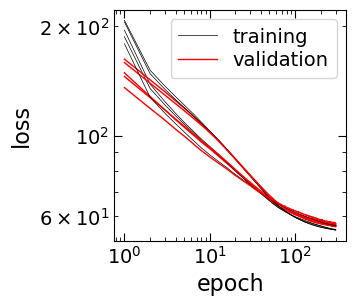

No. of latent dimensions: 61


In [9]:
show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']
if Ensemble:
    Avg_Wts = ae.display_summary(show_keys=show_keys,train_keys=['lrate','check_after'],
                                 return_avg_wts=True)
    n_latent = ae.ensemble[ae.keys[0]]['net'].n_latent
    Wts_Text = "$\\langle \\, N_{{\\rm wts}} \\, \\rangle = {0:.1f}$".format(Avg_Wts)
else:
    print('Best test stat = {0:.3e}'.format(bts))
    print('Setup params:')
    for pkey in show_keys:
        print('... '+pkey+':',ae.params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in ae.params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(ae.params['lrelu_slope']))
    print('... check_after: {0:d}'.format(ptrain['check_after']))
    print('... lrate: {0:.2e}'.format(ptrain['lrate']))
    
    N_free = ae.calc_N_freeparams()
    print('No. of free params optimized = {0:d}\n'.format(N_free))
    Wts_Text = "$N_{{\\rm wts}} = {0:d}$".format(N_free)

    n_latent = ae.n_latent
    
    plt.figure(figsize=(3,3))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(ae.net.epochs,ae.net.training_loss,'k-',lw=0.5,label='training')
    plt.plot(ae.net.epochs,ae.net.val_loss,'r-',lw=1,label='validation')
    plt.legend()
    plt.show()
print('No. of latent dimensions:',n_latent)

## Plots

### Reconstruction behaviour

Writing to file: autoencoder/plots/mnist_all_ens_default_recon.pdf


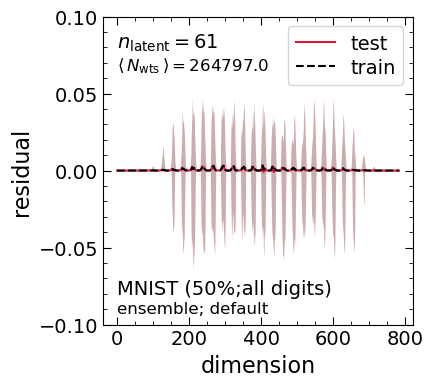

In [10]:
X_pred = ae.predict(X_test)
residual = X_pred - X_test
X_pred_train = ae.predict(X_train)
residual_train = X_pred_train - X_train
if Example == 'svd':
    residual /=  (X_test + 1e-15)
    residual_train /=  (X_train + 1e-15)

percs = [16,50,84]
# storage for 16,50,84 perc, per-dimension
res_percs = np.zeros((3,ae.n0)) 
res_percs_train = np.zeros((3,ae.n0)) 

for p in range(3):
    res_percs[p] = np.percentile(residual,percs[p],axis=1)
    res_percs_train[p] = np.percentile(residual_train,percs[p],axis=1)

dim_vals = np.arange(ae.n0)
plt.figure(figsize=(4,4))
ylim = 0.1 if Example == 'mnist' else 1.0
plt.ylim(-ylim,ylim)
plt.xlabel('dimension')
plt.ylabel('residual')
plt.plot(dim_vals,res_percs[1],'-',c='crimson',label='test')
plt.fill_between(dim_vals,res_percs[2],res_percs[0],lw=0,color='red',alpha=0.2)
plt.plot(dim_vals,res_percs_train[1],'--',c='k',label='train')
plt.fill_between(dim_vals,res_percs_train[2],res_percs_train[0],lw=0,color='gray',alpha=0.4)
plt.text(0.1,-0.08 if Example == 'mnist' else 0.75,ExDict[Example]['text'],fontsize=FS3)
plt.text(0.1,-0.0925 if Example == 'mnist' else 0.6,Ensemble_Text+'; '+Noise_Text,fontsize=FSS)
plt.text(0.1,0.08 if Example == 'mnist' else -0.75,"$n_{{\\rm latent}} = {0:d}$".format(n_latent),fontsize=FS3)
plt.text(0.1,0.065 if Example == 'mnist' else -0.9,Wts_Text,fontsize=FSS)
plt.legend(loc='upper right')
plt.minorticks_on()
if Save_Fig:
    figfile = Plot_Root_Final + 'recon.pdf'
    print('Writing to file:',figfile)
    plt.savefig(figfile,bbox_inches='tight')
plt.show()

TRAINING SAMPLES
Writing to file: autoencoder/plots/mnist_all_ens_default_gen_train.pdf


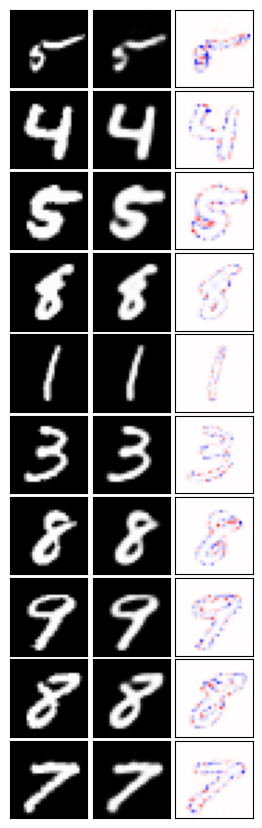

TEST SAMPLES
Writing to file: autoencoder/plots/mnist_all_ens_default_gen_test.pdf


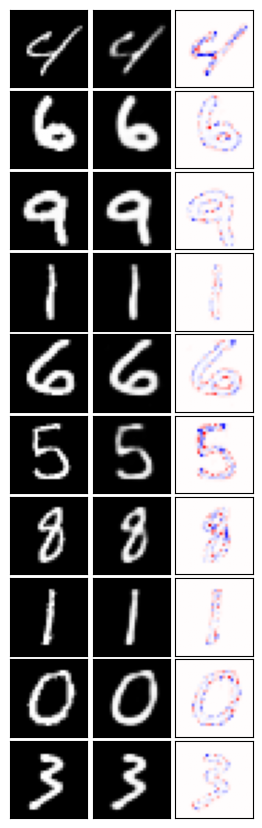

In [11]:
if Example == 'mnist':
    n_show = 10
    rng_show = np.random.RandomState(42)
    ind_show = rng_show.choice(X_test.shape[1],size=n_show,replace=False)
    orig_dim = int(np.sqrt(X_test.shape[0]))
    
    X_test_show = X_test[:,ind_show].T.copy()
    X_pred_show = X_pred[:,ind_show].T.copy()
    residual_show = residual[:,ind_show].T.copy()
    
    X_test_show = np.reshape(X_test_show,(n_show,orig_dim,orig_dim))
    X_pred_show = np.reshape(X_pred_show,(n_show,orig_dim,orig_dim))
    residual_show = np.reshape(residual_show,(n_show,orig_dim,orig_dim))

    X_train_show = X_train[:,ind_show].T.copy()
    X_pred_train_show = X_pred_train[:,ind_show].T.copy()
    residual_train_show = residual_train[:,ind_show].T.copy()
    
    X_train_show = np.reshape(X_train_show,(n_show,orig_dim,orig_dim))
    X_pred_train_show = np.reshape(X_pred_train_show,(n_show,orig_dim,orig_dim))
    residual_train_show = np.reshape(residual_train_show,(n_show,orig_dim,orig_dim))

    print('TRAINING SAMPLES')
    plt.figure(figsize=(1.05*3,1.05*n_show))
    gs = gridspec.GridSpec(n_show,3,width_ratios=[1,1,1],wspace=0.05,height_ratios=[1]*n_show,hspace=0.05)
    for n in range(n_show):
        for i in range(3):
            if i==0:
                data_show = X_train_show[n]
            elif i==1:
                data_show = X_pred_train_show[n]
            else:
                data_show = residual_train_show[n]
            ax = plt.subplot(gs[3*n + i])
            ax.set_xticklabels('')
            ax.set_yticklabels('')
            ax.set_xticks([])
            ax.set_yticks([])
            im = ax.imshow(data_show, cmap="gray" if i < 2 else "seismic",vmin=0 if i < 2 else -1,vmax=1)
            # plt.colorbar(im)
    if Save_Fig:
        figfile = Plot_Root_Final + 'gen_train.pdf'
        print('Writing to file:',figfile)
        plt.savefig(figfile,bbox_inches='tight')
    plt.show()    
        
    print('TEST SAMPLES')
    plt.figure(figsize=(1.05*3,1.05*n_show))
    gs = gridspec.GridSpec(n_show,3,width_ratios=[1,1,1],wspace=0.05,height_ratios=[1]*n_show,hspace=0.05)
    for n in range(n_show):
        for i in range(3):
            if i==0:
                data_show = X_test_show[n]
            elif i==1:
                data_show = X_pred_show[n]
            else:
                data_show = residual_show[n]
            ax = plt.subplot(gs[3*n + i])
            ax.set_xticklabels('')
            ax.set_yticklabels('')
            ax.set_xticks([])
            ax.set_yticks([])
            im = ax.imshow(data_show, cmap="gray" if i < 2 else "seismic",vmin=0 if i < 2 else -1,vmax=1)
            # plt.colorbar(im)
    if Save_Fig:
        figfile = Plot_Root_Final + 'gen_test.pdf'
        print('Writing to file:',figfile)
        plt.savefig(figfile,bbox_inches='tight')
    plt.show()

### Encoder behaviour

Writing to file: autoencoder/plots/mnist_all_ens_default_encoder.pdf


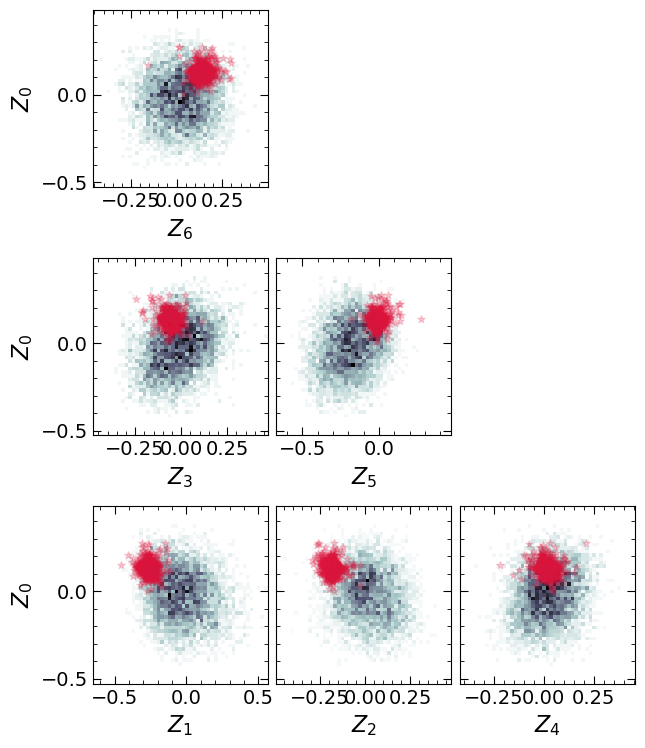

In [12]:
Z = ae.predict(X_test,autoenc='encoder') if Ensemble else ae.encoder.predict(X_test)
Z_ex = np.zeros((ae.n0,Z.shape[0]))
for d in range(ae.n0):
    unit_X = ml.one_hot(np.array([[d+1]]),ae.n0)
    Z_ex[d] = ae.predict(unit_X,autoenc='encoder')[:,0] if Ensemble else ae.encoder.predict(unit_X)[:,0]
Z_ex = Z_ex.T

plt.figure(figsize=(7,7/(2*0.4)))
gs = gridspec.GridSpec(3,3,height_ratios=[1]*3,width_ratios=[1]*3,hspace=0.4,wspace=0.05)
gsid = [-3,-2,-6,-1,-5,-9,-4,-8,-7]
Z0min,Z0max = np.percentile(Z[0],1),np.percentile(Z[0],99)
Z0min,Z0max = np.min([Z0min,Z_ex[0].min()]),np.max([Z0max,Z_ex[0].max()])
for z in range(np.min([6,Z.shape[0]-1])):
    Zzmin,Zzmax = np.percentile(Z[z+1],1),np.percentile(Z[z+1],99)
    Zzmin,Zzmax = np.min([Zzmin,Z_ex[z+1].min()]),np.max([Zzmax,Z_ex[z+1].max()])
    ymin,ymax = Z0min-0.2*np.max([np.fabs(Z0min),1]),Z0max+0.2*np.max([np.fabs(Z0max),1])
    xmin,xmax = Zzmin-0.2*np.max([np.fabs(Zzmin),1]),Zzmax+0.2*np.max([np.fabs(Zzmax),1])
    ax = plt.subplot(gs[gsid[z]])
    if (gsid[z] % 3) != 0:
        ax.set_yticklabels('')
    else:
        ax.set_ylabel("$Z_{{0}}$")
    ax.set_xlabel("$Z_{{{0:d}}}$".format(z+1))
    ax.hist2d(Z[z+1],Z[0],bins=[np.linspace(xmin,xmax,50),np.linspace(ymin,ymax,50)],cmap='bone_r')
    ax.scatter(Z_ex[z+1],Z_ex[0],c='crimson',marker='*',s=30,label='unit vecs',alpha=0.2 if Example=='mnist' else 0.7)
    ax.minorticks_on()

if Save_Fig:
    figfile = Plot_Root_Final + 'encoder.pdf'
    print('Writing to file:',figfile)
    plt.savefig(figfile,bbox_inches='tight')

plt.show()